### Folder make

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# cd content/drive/MyDrive/
# import os
# os.mkdir("Datalab")
# cd Datalab
# os.mkdir("practice")
# cd practice

In [ ]:
# cd drive/MyDrive/Datalab/practice

/content/drive/MyDrive/Datalab/practice


In [ ]:
pwd

'/content/drive/MyDrive/Datalab/practice'

### Import

In [ ]:
import os
import shutil
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim


### data load

In [ ]:
df = pd.read_csv("../data/daily-median-income.csv")

In [ ]:
df.head()

,Entity,Code,Year,Median (2021 prices)
0,Albania,ALB,1996,7.419331
1,Albania,ALB,2002,7.117155
2,Albania,ALB,2005,8.300112
3,Albania,ALB,2008,8.939034
4,Albania,ALB,2012,8.768968


In [ ]:
years = sorted(df["Year"].unique())

df_wide = (
    df.pivot(index="Entity", columns="Year", values="Median (2021 prices)")
    .reindex(columns=years)
)

In [ ]:
df_wide.head()

Year,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Entity,,,,,,,,,,,,,,,,,,,,,
Albania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.934010,10.841160,12.386626,12.356349,12.838601,NaN,NaN,NaN,NaN,NaN
Algeria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Angola,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,3.879510,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Argentina (urban),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.814356,24.032763,21.788387,20.671300,18.155481,19.553210,18.891396,18.541737,19.133984,NaN
Armenia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8.863737,8.011298,7.971968,7.717232,7.608540,7.749302,7.719168,7.726025,NaN,NaN


In [ ]:
valid_years = df_wide.columns[df_wide.notna().mean() > 0.2]
df_trim = df_wide[valid_years]

In [ ]:
df_trim

Year,1992,1993,1995,1996,1997,1998,1999,2000,2001,2002,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Entity,,,,,,,,,,,,,,,,,,,,,
Albania,NaN,NaN,NaN,7.419331,NaN,NaN,NaN,NaN,NaN,7.117155,...,8.827485,10.687345,10.934010,10.841160,12.386626,12.356349,12.838601,NaN,NaN,NaN
Algeria,NaN,NaN,6.518008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Angola,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.300380,NaN,NaN,...,NaN,NaN,NaN,NaN,3.879510,NaN,NaN,NaN,NaN,NaN
Argentina (urban),17.271112,17.652037,15.778318,15.137418,16.209293,14.829559,14.727661,14.007322,12.500795,8.575318,...,21.966805,NaN,22.814356,24.032763,21.788387,20.671300,18.155481,19.553210,18.891396,18.541737
Armenia,NaN,NaN,NaN,NaN,NaN,NaN,4.513009,NaN,4.335291,4.546867,...,7.739168,8.170164,8.863737,8.011298,7.971968,7.717232,7.608540,7.749302,7.719168,7.726025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Western and Central Africa (WB),2.200000,2.200000,2.180000,2.200000,2.240000,2.300000,2.340000,2.380000,2.460000,2.580000,...,3.520000,3.560000,3.640000,3.760000,3.880000,3.960000,3.780000,3.760000,3.760000,3.740000
World,3.620000,3.640000,3.840000,3.920000,3.980000,3.960000,3.980000,4.100000,4.200000,4.340000,...,7.250000,7.500000,7.750000,7.950000,8.200000,8.350000,8.200000,8.600000,8.700000,9.000000
Yemen,NaN,NaN,NaN,NaN,NaN,5.558853,NaN,NaN,NaN,NaN,...,3.798047,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_1992 = df_wide.loc[:, df_wide.columns >= 1992]
df_1992.head()

Year,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Entity,,,,,,,,,,,,,,,,,,,,,
Albania,NaN,NaN,NaN,NaN,7.419331,NaN,NaN,NaN,NaN,NaN,...,10.934010,10.841160,12.386626,12.356349,12.838601,NaN,NaN,NaN,NaN,NaN
Algeria,NaN,NaN,NaN,6.518008,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Angola,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.300380,NaN,...,NaN,NaN,3.879510,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Argentina (urban),17.271112,17.652037,17.068842,15.778318,15.137418,16.209293,14.829559,14.727661,14.007322,12.500795,...,22.814356,24.032763,21.788387,20.671300,18.155481,19.553210,18.891396,18.541737,19.133984,NaN
Armenia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.513009,NaN,4.335291,...,8.863737,8.011298,7.971968,7.717232,7.608540,7.749302,7.719168,7.726025,NaN,NaN


➡️ USA has the data form 1963
but others are not. So I checked years what has the data over the 20%.
that's 1992. so I cutted the data from 1992 to 2024.


In [ ]:
df_init = df_1992.copy()

df_init = df_init.interpolate(axis=1, limit_direction="both") # linear interpolation

df_init = df_init.fillna(df_init.mean()) # extra Nan as mean of every data

### VAE

In [ ]:
X = torch.tensor(df_init.values, dtype=torch.float32)
X.shape # (number of countries, number of years)

torch.Size([193, 34])

In [ ]:
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, 64)
        self.mu = nn.Linear(64, latent_dim)
        self.logvar = nn.Linear(64, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, 64)
        self.fc3 = nn.Linear(64, input_dim)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return self.fc3(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


In [ ]:
input_dim = X.shape[1]   # 연도 수
latent_dim = 3           # 국가 패턴 차원
epochs = 5000            # 학습 반복 횟수
learning_rate = 1e-3




In [ ]:
model = VAE(input_dim, latent_dim)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

def vae_loss(x, recon, mu, logvar):
    recon_loss = torch.mean((x - recon)**2)
    kl = -0.5 * torch.mean(1 + logvar - mu**2 - logvar.exp())
    return recon_loss + kl


model.train()

for epoch in range(epochs):
    optimizer.zero_grad()

    recon, mu, logvar = model(X)
    loss = vae_loss(X, recon, mu, logvar)

    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

Epoch 0 | Loss: 6284218204160.0000
Epoch 500 | Loss: 520.8268
Epoch 1000 | Loss: 520.5393
Epoch 1500 | Loss: 519.6587
Epoch 2000 | Loss: 518.3737
Epoch 2500 | Loss: 516.8736
Epoch 3000 | Loss: 515.1065
Epoch 3500 | Loss: 512.7280
Epoch 4000 | Loss: 509.0779
Epoch 4500 | Loss: 503.9519


In [ ]:
model.eval()
with torch.no_grad():
    recon_all, _, _ = model(X)

recon_np = recon_all.numpy()

df_filled = df_1992.copy()
mask = df_1992.isna()

# 반복문으로 각 열/행에 맞춰서 대체
for col in df_1992.columns:
    df_filled.loc[mask[col], col] = recon_np[mask[col].values, df_1992.columns.get_loc(col)]

In [ ]:
df_filled.head() # changed

Year,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Entity,,,,,,,,,,,,,,,,,,,,,
Albania,0.641294,0.453001,0.335175,-0.235843,7.419331,0.553067,0.414198,0.627941,0.541383,0.639983,...,10.934010,10.841160,12.386626,12.356349,12.838601,0.101600,0.363388,0.620868,1.833833,0.208021
Algeria,0.782989,0.642711,0.318814,6.518008,0.599332,0.882685,0.121561,0.839805,1.285254,1.489073,...,1.065531,0.221326,0.981028,0.727903,0.684889,-0.584802,0.480242,0.854874,2.192352,-0.045616
Angola,0.767219,0.402050,0.326603,0.634746,0.842784,0.868277,0.175004,1.165393,5.300380,1.391760,...,0.983733,0.017271,3.879510,0.674474,0.416587,-0.229712,0.443518,0.699146,1.905412,-0.299553
Argentina (urban),17.271112,17.652037,17.068842,15.778318,15.137418,16.209293,14.829559,14.727661,14.007322,12.500795,...,22.814356,24.032763,21.788387,20.671300,18.155481,19.553210,18.891396,18.541737,19.133984,-0.649381
Armenia,0.771902,0.668496,0.282151,0.171563,0.787554,0.833790,0.580308,4.513009,0.845260,4.335291,...,8.863737,8.011298,7.971968,7.717232,7.608540,7.749302,7.719168,7.726025,1.978848,-0.019101


In [ ]:
df_init.head() # linear

Year,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Entity,,,,,,,,,,,,,,,,,,,,,
Albania,7.419331,7.419331,7.419331,7.419331,7.419331,7.368968,7.318605,7.268243,7.217880,7.167517,...,10.934010,10.841160,12.386626,12.356349,12.838601,12.838601,12.838601,12.838601,12.838601,12.838601
Algeria,6.518008,6.518008,6.518008,6.518008,6.680275,6.842542,7.004808,7.167075,7.329342,7.491608,...,9.114276,9.114276,9.114276,9.114276,9.114276,9.114276,9.114276,9.114276,9.114276,9.114276
Angola,5.300380,5.300380,5.300380,5.300380,5.300380,5.300380,5.300380,5.300380,5.300380,5.304602,...,4.170440,4.024975,3.879510,3.879510,3.879510,3.879510,3.879510,3.879510,3.879510,3.879510
Argentina (urban),17.271112,17.652037,17.068842,15.778318,15.137418,16.209293,14.829559,14.727661,14.007322,12.500795,...,22.814356,24.032763,21.788387,20.671300,18.155481,19.553210,18.891396,18.541737,19.133984,19.133984
Armenia,4.513009,4.513009,4.513009,4.513009,4.513009,4.513009,4.513009,4.513009,4.424150,4.335291,...,8.863737,8.011298,7.971968,7.717232,7.608540,7.749302,7.719168,7.726025,7.726025,7.726025


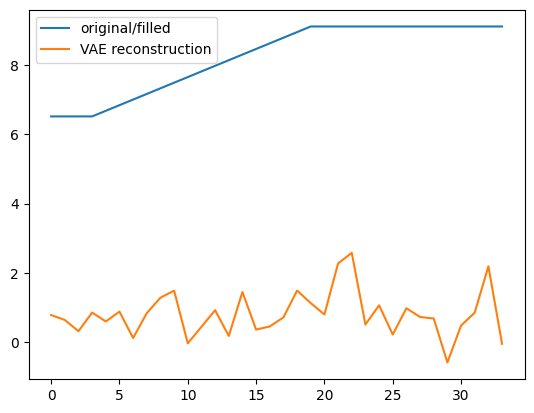

In [ ]:
import matplotlib.pyplot as plt

plt.plot(X[1].numpy(), label="original/filled")
plt.plot(recon_all[1].numpy(), label="VAE reconstruction")
plt.legend()
plt.show()

# git VAE

In [ ]:
cd /content

/content


In [ ]:
!git clone https://github.com/AntixK/PyTorch-VAE.git

Cloning into 'PyTorch-VAE'...
remote: Enumerating objects: 862, done.
remote: Counting objects: 100% (447/447), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 862 (delta 415), reused 403 (delta 403), pack-reused 415 (from 1)
Receiving objects: 100% (862/862), 46.46 MiB | 16.07 MiB/s, done.
Resolving deltas: 100% (621/621), done.


In [ ]:
cd /content/PyTorch-VAE

/content/PyTorch-VAE


In [ ]:
!pip install -r requirements.txt

Requested pytorch-lightning==1.5.6 from https://files.pythonhosted.org/packages/a4/5f/3ae279deedac8a5a8e3351e9fbfbadd5ce1859d0a315b867fdea19d19e94/pytorch_lightning-1.5.6-py3-none-any.whl (from -r requirements.txt (line 1)) has invalid metadata: .* suffix can only be used with `==` or `!=` operators
    torch (>=1.7.*)
           ~~~~~~^
Please use pip<24.1 if you need to use this version.
ERROR: Could not find a version that satisfies the requirement pytorch-lightning==1.5.6 (from versions: 0.0.2, 0.2, 0.2.2, 0.2.3, 0.2.4, 0.2.4.1, 0.2.5, 0.2.5.1, 0.2.5.2, 0.2.6, 0.3, 0.3.1, 0.3.2, 0.3.3, 0.3.4, 0.3.4.1, 0.3.5, 0.3.6, 0.3.6.1, 0.3.6.3, 0.3.6.4, 0.3.6.5, 0.3.6.6, 0.3.6.7, 0.3.6.8, 0.3.6.9, 0.4.0, 0.4.1, 0.4.2, 0.4.3, 0.4.4, 0.4.5, 0.4.6, 0.4.7, 0.4.8, 0.4.9, 0.5.0, 0.5.1, 0.5.1.2, 0.5.1.3, 0.5.2, 0.5.2.1, 0.5.3, 0.5.3.1, 0.5.3.2, 0.5.3.3, 0.6.0, 0.7.1, 0.7.3, 0.7.5, 0.7.6, 0.8.1, 0.8.3, 0.8.4, 0.8.5, 0.9.0, 0.10.0, 1.0.0, 1.0.1, 1.0.2, 1.0.3, 1.0.4, 1.0.5, 1.0.6, 1.0.7, 1.0.8, 1.1.0, 1

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset

X_tensor = torch.tensor(df_filled.values, dtype=torch.float32)
dataset = TensorDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [ ]:
from models import VanillaVAE

# feature 수에 맞게 latent_dim 설정
model = VanillaVAE(in_channels=X_tensor.shape[1], latent_dim=16)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


ModuleNotFoundError: No module named 'model'

RuntimeError: Expected 3D (unbatched) or 4D (batched) input to conv2d, but got input of size: [32, 34]

In [ ]:
## because of git VAE model is suitable with image data